# Decision Trees -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 07 -- Session 1 of 2

Companion notebook to the Decision Trees slides. Same approach as every notebook so far: every
claim gets a real, visible demonstration. The single biggest advantage of trees is that you can
genuinely *look* at one -- so `plot_tree` appears constantly here, more than in any notebook so
far, because seeing the actual flowchart is the fastest way to build real intuition.

**session structure:**
1. The core idea -- a tiny tree, built and visualized directly
2. How a tree decides what to ask -- Gini impurity, computed by hand
3. Recursive splitting -- building a real tree, and reading it
4. Why trees overfit -- an unpruned tree, and the train/test gap it produces
5. Pre-pruning -- `max_depth`, `min_samples_split`, `min_samples_leaf`
6. Post-pruning -- cost-complexity pruning with `ccp_alpha`
7. Feature importance, and its correlated-feature blind spot
8. The axis-aligned limitation, visualized directly
9. Regression trees -- the same idea, a numeric target
10. The full workflow, tied together

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_classification, make_moons
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.5


---
## Part 1 -- The Core Idea: a Tiny Tree, Built and Read Directly

**The mental model:** a tree is a flowchart of yes/no questions, learned from data. The fastest
way to believe that is to build the smallest possible one and read it.

In [2]:
# A self-contained churn-style dataset -- same shape of problem as the capstone and the
# Classification notebook, kept here so this notebook runs on its own.
rng = np.random.default_rng(42)
n = 800
tenure_months = rng.integers(1, 72, n)
monthly_charges = rng.normal(70, 25, n).clip(20, 150)
contract_month_to_month = rng.choice([0, 1], n, p=[0.45, 0.55])

churn_score = (-0.04 * tenure_months + 0.02 * monthly_charges + 1.3 * contract_month_to_month - 2.3
               + rng.normal(0, 1, n))
churn_prob_true = 1 / (1 + np.exp(-churn_score))
churn = rng.binomial(1, churn_prob_true)

churn_df = pd.DataFrame({'tenure_months': tenure_months, 'monthly_charges': monthly_charges,
                          'contract_month_to_month': contract_month_to_month, 'churn': churn})
print(f'Churn rate: {churn_df["churn"].mean():.1%}')

X = churn_df[['tenure_months', 'monthly_charges', 'contract_month_to_month']]
y = churn_df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Churn rate: 26.1%


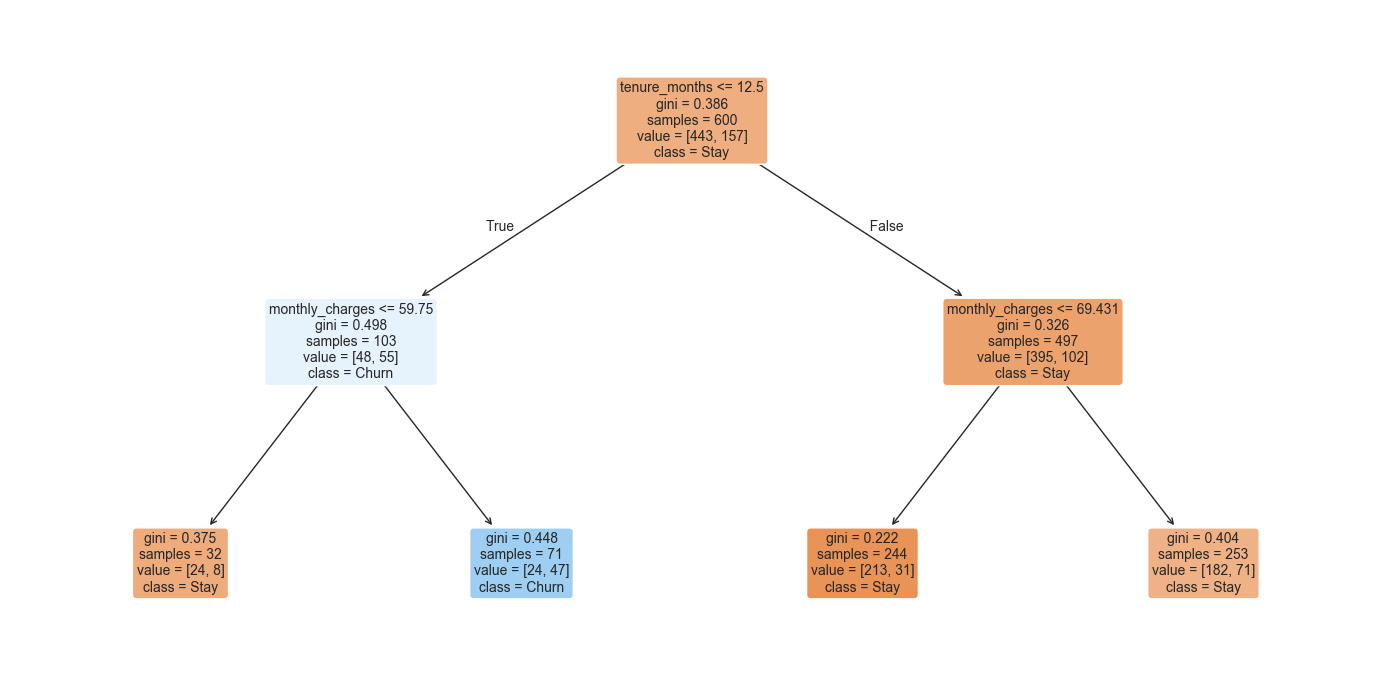

In [3]:
# A deliberately tiny tree -- depth 2 -- small enough to read every single question.
tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tiny_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tiny_tree, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=10, ax=ax)
plt.tight_layout()
plt.show()

**Read this exactly like a flowchart, top to bottom.** The very top box is the root -- the single
question the tree found most useful out of every feature and every possible threshold. Each box
below shows: the question, the Gini score (Part 2), how many training rows reached that box, and
the class breakdown among them. The colored leaves at the bottom are the tree's final answers --
darker color means a more confident, purer prediction.

---
## Part 2 -- How a Tree Decides What to Ask: Gini Impurity, by Hand

In [4]:
def gini_impurity(labels):
    # 1 - sum of (fraction of each class)^2 -- 0 means perfectly pure, 0.5 is maximally mixed
    # for two classes.
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    fractions = counts / len(labels)
    return 1 - np.sum(fractions ** 2)

# A perfectly pure group, and a maximally mixed one -- exactly the slides' two examples.
pure_group = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
mixed_group = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

print(f'Pure group (all churned):     Gini = {gini_impurity(pure_group):.3f}')
print(f'Mixed group (50/50 split):    Gini = {gini_impurity(mixed_group):.3f}')

Pure group (all churned):     Gini = 0.000
Mixed group (50/50 split):    Gini = 0.500


In [5]:
def weighted_gini_of_split(left_labels, right_labels):
    n_left, n_right = len(left_labels), len(right_labels)
    n_total = n_left + n_right
    return (n_left / n_total) * gini_impurity(left_labels) + (n_right / n_total) * gini_impurity(right_labels)

# Try a few candidate thresholds on 'tenure_months' by hand, exactly the way the tree itself does
# internally -- and see which one the tree actually picked as its root question.
candidate_thresholds = [6, 12, 24, 36, 48]
print(f"{'threshold':>10} | {'weighted Gini':>14}")
for t in candidate_thresholds:
    left = y_train[X_train['tenure_months'] < t]
    right = y_train[X_train['tenure_months'] >= t]
    wg = weighted_gini_of_split(left, right)
    print(f'{t:>10} | {wg:>14.4f}')

print(f"\nThe tree's actual root question: {tiny_tree.tree_.feature[0]} "
      f"(0=tenure_months) at threshold {tiny_tree.tree_.threshold[0]:.1f}")

 threshold |  weighted Gini
         6 |         0.3754
        12 |         0.3593
        24 |         0.3624
        36 |         0.3664
        48 |         0.3765

The tree's actual root question: 0 (0=tenure_months) at threshold 12.5


**The threshold with the lowest weighted Gini above is the one worth splitting on** -- and it
should land close to whatever the tree actually chose as its root question, printed on the last
line. This is the entire "how does a tree decide" story, done by hand: try many candidates,
measure the resulting impurity, keep the best one. The real algorithm does this same check across
*every* feature and *every* possible threshold, not just five candidates on one column -- that's
the only difference between this cell and what `.fit()` does internally.

---
## Part 3 -- Recursive Splitting: Building and Reading a Real Tree

In [6]:
full_tree = DecisionTreeClassifier(random_state=42)   # no limits at all -- grows until pure or empty
full_tree.fit(X_train, y_train)

print(f'Unrestricted tree depth: {full_tree.get_depth()}')
print(f'Unrestricted tree leaf count: {full_tree.get_n_leaves()}')
print(f'Training rows: {len(X_train)}')

Unrestricted tree depth: 26
Unrestricted tree leaf count: 175
Training rows: 600


**Notice the leaf count relative to the number of training rows.** A tree with dozens or hundreds
of leaves, on a dataset with only a few hundred rows, is a strong hint it's memorizing individual
rows rather than learning a general pattern -- exactly what Part 4 measures directly.

---
## Part 4 -- Why Trees Overfit So Easily

In [7]:
train_acc = accuracy_score(y_train, full_tree.predict(X_train))
test_acc = accuracy_score(y_test, full_tree.predict(X_test))

print(f'Unrestricted tree -- Train accuracy: {train_acc:.3f}   Test accuracy: {test_acc:.3f}')
print(f'Gap: {train_acc - test_acc:.3f}')

Unrestricted tree -- Train accuracy: 1.000   Test accuracy: 0.665
Gap: 0.335


**That gap is the overfitting story from Lecture 01, now with real numbers.** Near-perfect (or
perfect) training accuracy paired with a noticeably lower test accuracy means the tree learned the
training set's specific quirks and noise, not the general pattern underneath -- it memorized
rather than generalized. This is the default behavior of an unrestricted tree, not an edge case.

---
## Part 5 -- Pre-Pruning: Limits Set Before Training

In [8]:
depths_to_try = [1, 2, 3, 4, 5, 8, 12, None]
results = []
for depth in depths_to_try:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    results.append({
        'max_depth': depth if depth else 'None (unlimited)',
        'train_acc': accuracy_score(y_train, tree.predict(X_train)),
        'test_acc': accuracy_score(y_test, tree.predict(X_test)),
        'n_leaves': tree.get_n_leaves(),
    })

results_df = pd.DataFrame(results)
print(results_df)

          max_depth  train_acc  test_acc  n_leaves
0                 1   0.750000     0.695         2
1                 2   0.776667     0.710         4
2                 3   0.786667     0.700         8
3                 4   0.790000     0.695        15
4                 5   0.806667     0.675        26
5                 8   0.865000     0.640        71
6                12   0.930000     0.655       119
7  None (unlimited)   1.000000     0.665       175


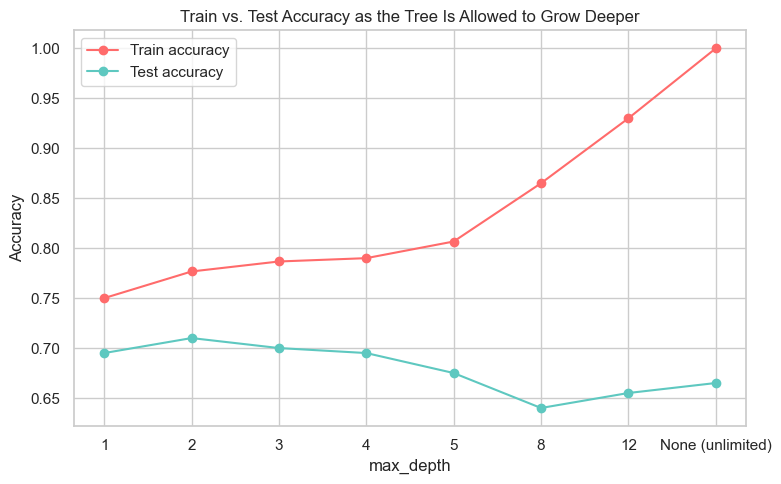

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x_labels = [str(d) for d in results_df['max_depth']]
ax.plot(x_labels, results_df['train_acc'], marker='o', color='#ff6b6b', label='Train accuracy')
ax.plot(x_labels, results_df['test_acc'], marker='o', color='#5ec8c0', label='Test accuracy')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs. Test Accuracy as the Tree Is Allowed to Grow Deeper')
ax.legend()
plt.tight_layout()
plt.show()

**Read the two lines relative to each other, not in isolation.** Training accuracy climbs steadily
as `max_depth` increases -- more depth always lets the tree fit the training data better. Test
accuracy rises at first (the tree is learning real structure), then flattens or drops (the tree
starts fitting noise instead). The best `max_depth` is wherever the **test** line peaks -- not
wherever the training line is highest, which is nearly always at the far right.

---
## Part 6 -- Post-Pruning: Cost-Complexity Pruning

In [10]:
# cost_complexity_pruning_path finds the sequence of ccp_alpha values that actually produce
# different pruned trees -- rather than guessing values ourselves.
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
alpha_results = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring='accuracy')
    alpha_results.append({'ccp_alpha': alpha, 'cv_accuracy': scores.mean()})

alpha_df = pd.DataFrame(alpha_results)
best_alpha = alpha_df.loc[alpha_df['cv_accuracy'].idxmax(), 'ccp_alpha']
print(f'Best ccp_alpha found via cross-validation: {best_alpha:.5f}')

Best ccp_alpha found via cross-validation: 0.00880


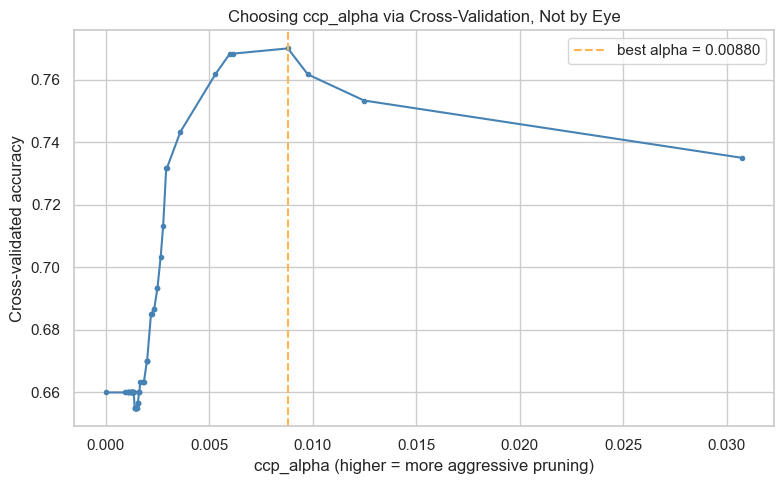

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_df['ccp_alpha'], alpha_df['cv_accuracy'], marker='o', color='steelblue', markersize=3)
ax.axvline(best_alpha, color='#ffb454', linestyle='--', label=f'best alpha = {best_alpha:.5f}')
ax.set_xlabel('ccp_alpha (higher = more aggressive pruning)')
ax.set_ylabel('Cross-validated accuracy')
ax.set_title('Choosing ccp_alpha via Cross-Validation, Not by Eye')
ax.legend()
plt.tight_layout()
plt.show()

**Exactly the same shape of decision as tuning `max_depth`, `alpha` for Ridge/Lasso, or `k` for
KNN** -- try a range of values, cross-validate each one, pick whichever generalizes best. Nothing
about pruning required a new way of thinking; it's Lecture 04's machinery, pointed at a new
hyperparameter.

---
## Part 7 -- Pruned vs. Unpruned, Side by Side

In [12]:
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X_train, y_train)

pruned_train_acc = accuracy_score(y_train, pruned_tree.predict(X_train))
pruned_test_acc = accuracy_score(y_test, pruned_tree.predict(X_test))

print(f"{'':>20} {'Train acc':>10} {'Test acc':>10} {'Gap':>8} {'Leaves':>8}")
print(f"{'Unpruned':>20} {train_acc:>10.3f} {test_acc:>10.3f} {train_acc-test_acc:>8.3f} {full_tree.get_n_leaves():>8}")
print(f"{'Pruned':>20} {pruned_train_acc:>10.3f} {pruned_test_acc:>10.3f} "
      f"{pruned_train_acc-pruned_test_acc:>8.3f} {pruned_tree.get_n_leaves():>8}")

                      Train acc   Test acc      Gap   Leaves
            Unpruned      1.000      0.665    0.335      175
              Pruned      0.777      0.710    0.067        4


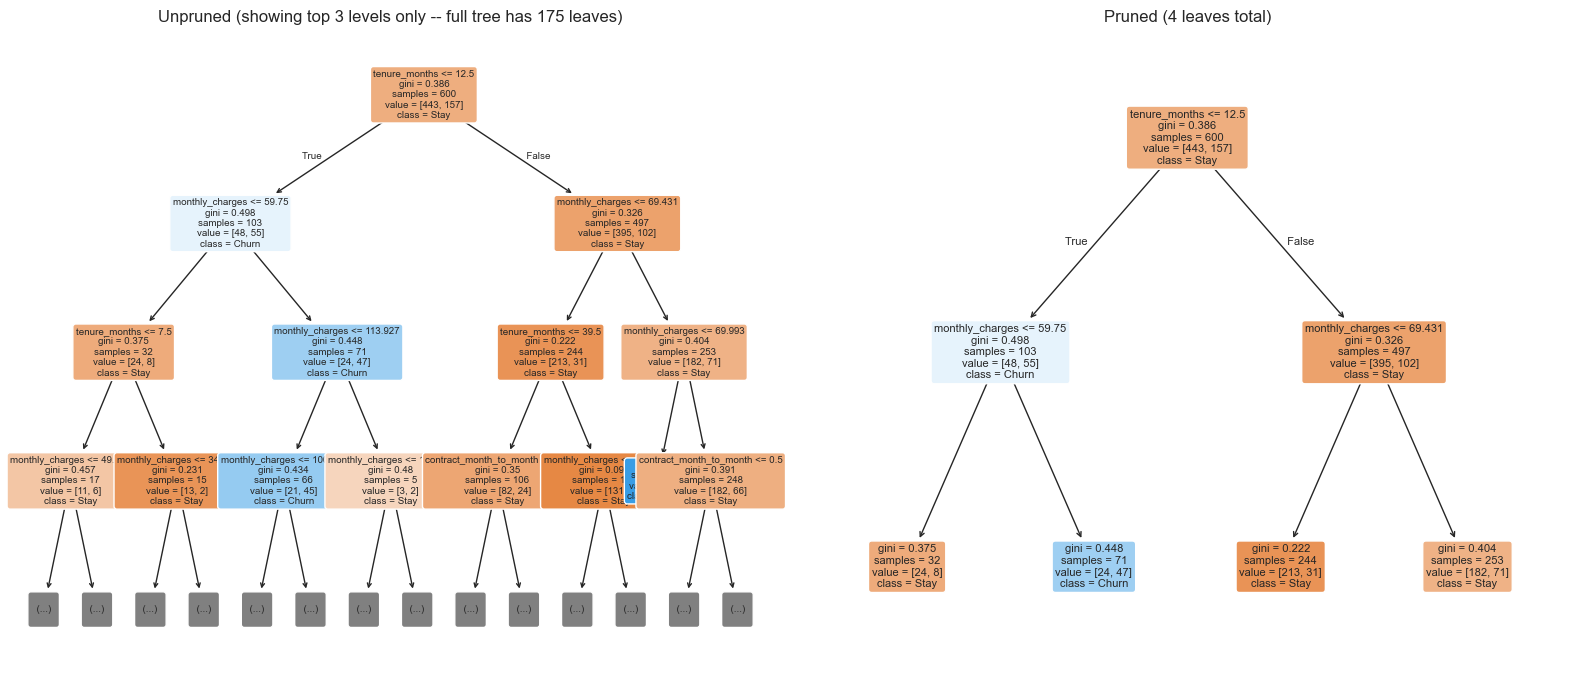

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_tree(full_tree, max_depth=3, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=7, ax=axes[0])
axes[0].set_title(f'Unpruned (showing top 3 levels only -- full tree has {full_tree.get_n_leaves()} leaves)')

plot_tree(pruned_tree, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title(f'Pruned ({pruned_tree.get_n_leaves()} leaves total)')
plt.tight_layout()
plt.show()

**The pruned tree looks smaller and "less impressive" -- and that's exactly the point.** Its
train/test gap should be noticeably smaller than the unpruned tree's, meaning its training
accuracy is a much more honest preview of how it'll perform on new data. A tree that looks
sophisticated because it's enormous is usually a tree that's overfit, not a tree that's smart.

---
## Part 8 -- Feature Importance, and Its Correlated-Feature Blind Spot

                   feature  importance
0            tenure_months    0.580132
1          monthly_charges    0.419868
2  contract_month_to_month    0.000000


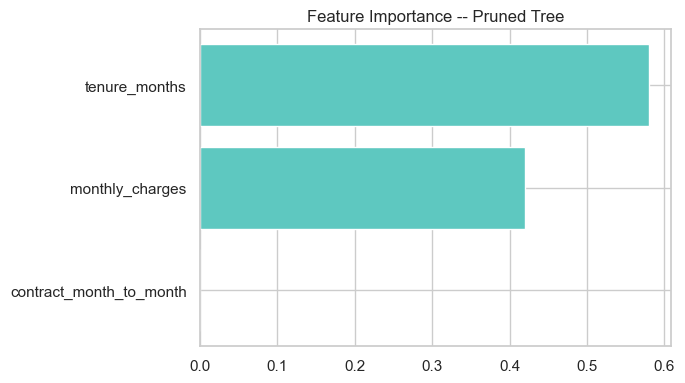

In [14]:
importance_df = pd.DataFrame({'feature': X.columns, 'importance': pruned_tree.feature_importances_}) \
                   .sort_values('importance', ascending=False)
print(importance_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df['feature'], importance_df['importance'], color='#5ec8c0')
ax.invert_yaxis()
ax.set_title('Feature Importance -- Pruned Tree')
plt.tight_layout()
plt.show()

In [15]:
# Now add a near-duplicate of tenure_months and refit, to see the correlated-feature blind spot
# from the slides directly -- reusing the same demonstration idea as Lecture 03's VIF/RFE section.
churn_df_dup = churn_df.copy()
churn_df_dup['tenure_months_v2'] = churn_df_dup['tenure_months'] + rng.normal(0, 2, n)

X_dup = churn_df_dup[['tenure_months', 'tenure_months_v2', 'monthly_charges', 'contract_month_to_month']]
X_train_dup, X_test_dup, y_train_dup, y_test_dup = train_test_split(
    X_dup, churn_df_dup['churn'], test_size=0.25, stratify=churn_df_dup['churn'], random_state=42)

tree_with_dup = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X_train_dup, y_train_dup)
dup_importance = pd.DataFrame({'feature': X_dup.columns, 'importance': tree_with_dup.feature_importances_}) \
                    .sort_values('importance', ascending=False)
print(dup_importance)

                   feature  importance
0            tenure_months    0.580132
2          monthly_charges    0.419868
1         tenure_months_v2    0.000000
3  contract_month_to_month    0.000000


**Look closely at `tenure_months_v2`'s importance: exactly zero.** All of the credit that would
have gone to tenure stayed entirely with the original `tenure_months` column -- the duplicate
contributed nothing, because once the tree already split on the original at the very first
question, the near-identical copy has nothing left to add along the same split points. **The
lesson isn't "importance gets vaguely split" -- it's sharper than that:** whichever correlated
feature happens to get used first can absorb *all* of the credit, leaving an equally-informative
twin looking completely irrelevant. Zero importance here does not mean `tenure_months_v2` carries
no real signal -- it means the tree never needed it once it already had the original.

---
## Part 9 -- The Axis-Aligned Limitation, Visualized

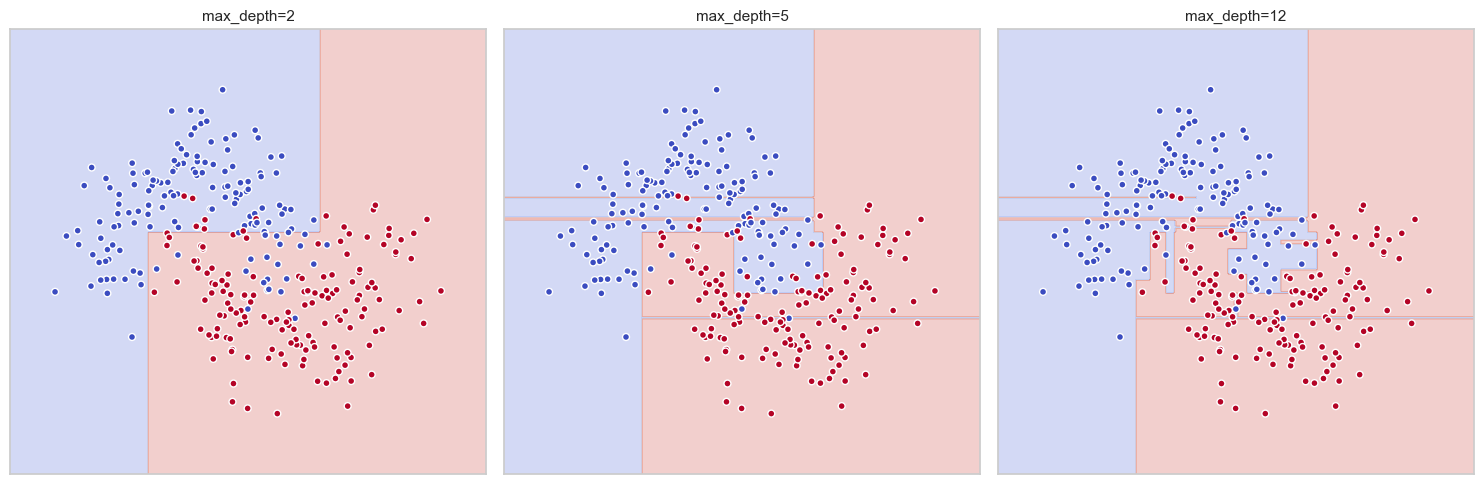

In [16]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='white', s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

# make_moons: two interleaving crescents -- a genuinely CURVED, diagonal-ish boundary, the kind
# a tree structurally struggles with using only straight, axis-aligned cuts.
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, depth in zip(axes, [2, 5, 12]):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_moons, y_moons)
    plot_decision_boundary(tree, X_moons, y_moons, ax, f'max_depth={depth}')
plt.tight_layout()
plt.show()

**Look at the boundary shape in every panel -- it's always a collection of rectangular blocks,
never a smooth curve, no matter how deep the tree grows.** A shallow tree (left) draws a crude
staircase; a deep tree (right) draws a much finer staircase, closely hugging the true curved
boundary -- but it's still fundamentally rectangles all the way down, built from many small
straight cuts. This is exactly the structural limitation the slides describe, and exactly the
contrast that will matter when SVM (Lecture 10) draws a smooth boundary directly.

---
## Part 10 -- Regression Trees: the Same Idea, a Numeric Target

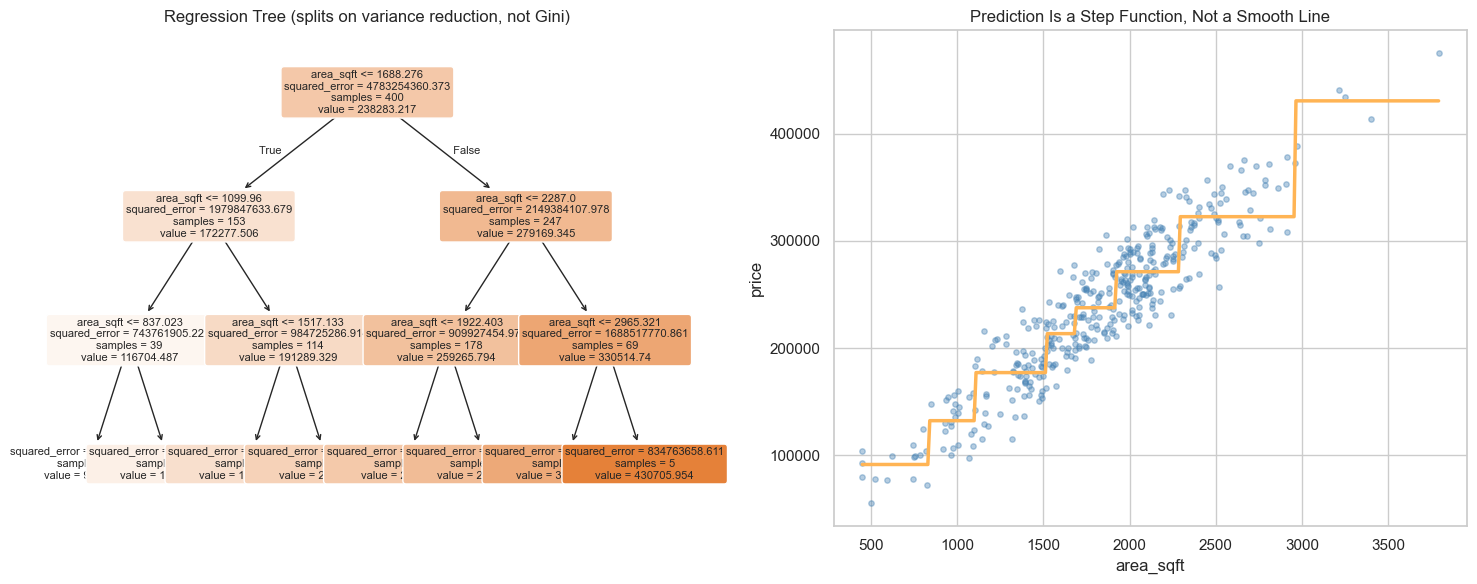

In [17]:
rng2 = np.random.default_rng(11)
area_sqft = rng2.normal(1800, 550, 400).clip(450, 4200)
price = (120 * area_sqft + 20000 + rng2.normal(0, 25000, 400)).clip(40000, None)

X_price = area_sqft.reshape(-1, 1)
y_price = price

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_price, y_price)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_tree(reg_tree, feature_names=['area_sqft'], filled=True, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title('Regression Tree (splits on variance reduction, not Gini)')

x_plot = np.linspace(area_sqft.min(), area_sqft.max(), 300).reshape(-1, 1)
y_plot = reg_tree.predict(x_plot)
axes[1].scatter(area_sqft, price, alpha=0.4, color='steelblue', s=15)
axes[1].plot(x_plot, y_plot, color='#ffb454', linewidth=2.5)
axes[1].set_xlabel('area_sqft')
axes[1].set_ylabel('price')
axes[1].set_title('Prediction Is a Step Function, Not a Smooth Line')

plt.tight_layout()
plt.show()

**Notice the prediction curve on the right is made of flat horizontal steps, not a smooth line
like Linear Regression's fit.** Each step corresponds to one leaf -- every house whose area falls
in that leaf's range gets the exact same predicted price, the average of the training houses that
landed there. More depth means more, narrower steps -- a closer approximation to a smooth curve,
but never actually smooth, which is a genuinely different shape of answer than Lecture 02's linear
fit.

---
## Part 11 -- The Full Workflow, Tied Together

In [18]:
param_grid = {'max_depth': [3, 4, 5, 6, 8, None], 'min_samples_leaf': [1, 5, 10, 20]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring='f1')
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best cross-validated F1: {grid.best_score_:.3f}')

final_tree = grid.best_estimator_
final_preds = final_tree.predict(X_test)
print()
print(classification_report(y_test, final_preds, target_names=['Stay', 'Churn']))

Best parameters: {'max_depth': 6, 'min_samples_leaf': 20}
Best cross-validated F1: 0.409

              precision    recall  f1-score   support

        Stay       0.76      0.89      0.82       148
       Churn       0.38      0.19      0.26        52

    accuracy                           0.71       200
   macro avg       0.57      0.54      0.54       200
weighted avg       0.66      0.71      0.67       200



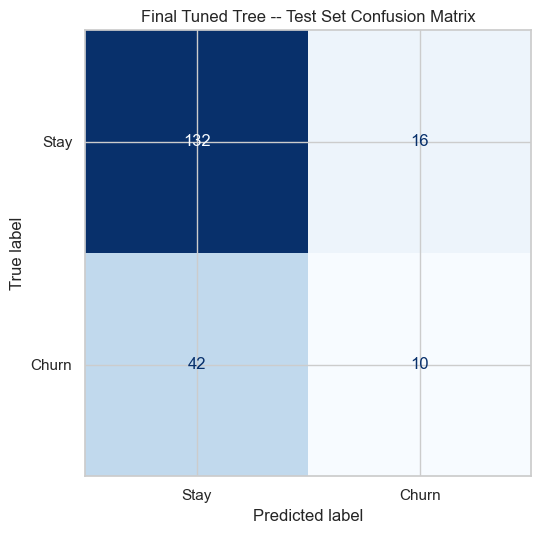

In [19]:
fig, ax = plt.subplots(figsize=(6, 5.5))
cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Final Tuned Tree -- Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

**Every step here is a technique from an earlier lecture, simply pointed at a new algorithm:**
`GridSearchCV` with `cv=StratifiedKFold(...)` from Lecture 04, scoring on F1 instead of accuracy
from Lecture 06, and a confusion matrix to close the loop. A decision tree is a new option to plug
into a pipeline you already know how to build and evaluate -- not a reason to learn a new
workflow.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **The core idea** | A flowchart of questions | `DecisionTreeClassifier()`, read directly with `plot_tree(model)` |
| **Splitting rule** | Gini impurity, by hand | `1 - sum(fraction_of_class ** 2)`, weighted across a split's two groups |
| **Building the tree** | Recursive splitting (CART) | Repeats the best-split search on every resulting group |
| **Overfitting** | An unrestricted tree memorizes | Compare train vs. test accuracy -- a large gap is the tell |
| **Pre-pruning** | Limits set in advance | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| **Post-pruning** | Grow fully, then trim | `cost_complexity_pruning_path()` + `ccp_alpha`, chosen via cross-validation |
| **Feature importance** | Total impurity reduction | `.feature_importances_` -- unstable when features are correlated |
| **Axis-aligned limitation** | Rectangular decision boundaries only | Visualized directly on `make_moons`' curved boundary |
| **Regression trees** | Variance reduction instead of Gini | `DecisionTreeRegressor()` -- predictions are step functions, not smooth curves |
| **Full workflow** | Nothing new, a new algorithm | `GridSearchCV` + `StratifiedKFold` + the Lecture 06 evaluation toolkit |

---

**Next session:** a single tree is unstable -- small data changes produce structurally different
trees. Ensembles (Random Forest and Gradient Boosting) fix exactly that, by training many trees
and combining their votes instead of trusting one.